# Affective Subspace Coverage & Emotion-wise Local PCA

**Two analyses building on `affective_subspace_interpretation.ipynb`.**

---

## Analysis 1 — Representational Coverage of the Affective Subspace

The earlier notebook showed PC1–PC4 explain ≈ 89 % of *centroid* variance.
That is a between-emotion, mean-level result.  Here we ask: **how much of the
individual-sample source-centered variation is explained by the same subspace?**

Concretely, for every `(source, emotion, intensity)` triple we:
* Compute source-centered activation `R[s, e, i]` (removes topic/base-text signal).
* Project onto three subspaces: **PC1–4**, **PC1–4 + v_intensity** (5-D), and **full 4096-D**.
* Report reconstruction EVR, emotion-label probe accuracy, intensity-label probe accuracy.
* If judge scores from the prior notebook exist, regress each attribute from PC projections.

---

## Analysis 2 — Emotion-wise Local PCA

Each named emotion may contain continuous internal structure: intensity gradients,
sub-types (e.g. panic vs. worry within fear), or context-dependent clusters.
We run a **per-emotion PCA** on source-centered activations and ask:
* How low-dimensional is each emotion's internal variation?
* Does intensity separate along the top local PC?
* How much does the local PC1 align with the global valence/arousal axes?
* What text archetypes sit at the extremes of each local axis?

**Primary layer**: 13.  Headline metrics repeated at layers 10 and 16.


## 0. Setup

In [1]:
from __future__ import annotations

import gc
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from emotionengine.steering_utils import unit
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupKFold
from sklearn.utils.extmath import randomized_svd

warnings.filterwarnings('ignore')

REPO_ROOT  = Path('../..').resolve()
ACT_DIR    = REPO_ROOT / 'activation' / 'emotion_rewrites'
NPY_PATH   = ACT_DIR / 'emotion_intensity_residual_stream.npy'
INFO_PATH  = ACT_DIR / 'emotion_intensity_residual_stream_info.json'
REWRITE_JSONL = REPO_ROOT / 'dataset' / 'emotion_rewrites' / 'emotion_rewrites.jsonl'
OUT_DIR    = REPO_ROOT / 'analysis' / 'emotion_intensity' / 'affective_subspace_coverage'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PREV_DIR   = REPO_ROOT / 'analysis' / 'emotion_intensity' / 'affective_subspace'

STEER_LAYER  = 13
AUX_LAYERS   = [10, 16]
K_PCS        = 4    # global PCs to use
K_LOCAL      = 6    # PCs per emotion in local PCA
MAX_SOURCES  = 2500  # source subsample (memory cap)
CHUNK        = 256   # sources per chunk for chunked EVR computation
FULL_D_NSRC  = 300   # sources used for the full-4096D probe (~7200 rows)
SEED         = 0

rng = np.random.default_rng(SEED)
sns.set_context('notebook')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150})

print('OUT_DIR =', OUT_DIR)


OUT_DIR = /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/affective_subspace_coverage


In [2]:
with open(INFO_PATH) as f:
    INFO = json.load(f)

LAYER_INDICES   = INFO['layer_indices']
EMOTION_ORDER   = INFO['emotion_order']
INTENSITY_ORDER = INFO['intensity_order']
SOURCE_IDS      = INFO['source_ids']
SHAPE           = tuple(INFO['shape'])
DTYPE           = INFO.get('dtype', 'float32')
N, N_EMO, N_INT, N_LAY, D = SHAPE
LI_MAP  = {l: i for i, l in enumerate(LAYER_INDICES)}
EMO_POS = {e: i for i, e in enumerate(EMOTION_ORDER)}
INT_POS = {lvl: i for i, lvl in enumerate(INTENSITY_ORDER)}

ACT = np.memmap(str(NPY_PATH), dtype=DTYPE, mode='r', shape=SHAPE)

# Stable source subsample (reproducible across notebooks via same SEED)
if N > MAX_SOURCES:
    SRC_IDX = np.sort(rng.choice(N, size=MAX_SOURCES, replace=False))
else:
    SRC_IDX = np.arange(N)
N_SUB      = len(SRC_IDX)
SRC_ID_SUB = [SOURCE_IDS[i] for i in SRC_IDX]

print(f'ACT shape = {SHAPE}, dtype = {DTYPE}')
print(f'Using {N_SUB}/{N} sources.  D = {D}')
print('Emotions   :', EMOTION_ORDER)
print('Intensities:', INTENSITY_ORDER)
print('Layers     :', LAYER_INDICES)


ACT shape = (22782, 8, 3, 6, 4096), dtype = float32
Using 2500/22782 sources.  D = 4096
Emotions   : ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
Intensities: ['low', 'medium', 'high']
Layers     : [8, 10, 13, 16, 19, 22]


In [3]:
# Load rewrite texts: (source_id, emotion, intensity_level) -> rewrite string
REGISTRY: dict[tuple, str] = {}
with open(REWRITE_JSONL) as f:
    for line in f:
        rec = json.loads(line)
        sid, lvl = rec['source_id'], rec['intensity_level']
        for emo in EMOTION_ORDER:
            text = rec.get(f'{emo}_rewrite', '')
            if text:
                REGISTRY[(sid, emo, lvl)] = text

print('Registry size =', len(REGISTRY), '(expected', N * N_EMO * N_INT, ')')


Registry size = 546768 (expected 546768 )


In [4]:
# ── Helper functions ──────────────────────────────────────────────────────────

def load_layer(layer: int) -> np.ndarray:
    """Return float32 (N_SUB, N_EMO, N_INT, D) for the given layer index."""
    li = LI_MAP[layer]
    return np.asarray(ACT[SRC_IDX, :, :, li, :], dtype=np.float32)

def source_center(X: np.ndarray) -> np.ndarray:
    """R[s,e,i] = X[s,e,i] - mean_{e'} X[s,e',i]  (removes topic content)."""
    return X - X.mean(axis=1, keepdims=True)

def emotion_centroids(R: np.ndarray) -> np.ndarray:
    """(N_EMO, D) = mean over (source, intensity)."""
    return R.mean(axis=(0, 2))

def build_global_basis(R: np.ndarray, X_raw: np.ndarray, k: int = K_PCS) -> dict:
    """Build the global affective subspace from emotion centroids + intensity vector."""
    C     = emotion_centroids(R)           # (N_EMO, D)
    mu_c  = C.mean(axis=0)                # (D,) grand centroid mean
    Cc    = (C - mu_c).astype(np.float64)
    _, S, Vt = np.linalg.svd(Cc, full_matrices=False)
    evr   = (S ** 2) / (S ** 2).sum()
    PCs   = Vt[:k].astype(np.float32)    # (k, D) orthonormal rows

    # Intensity direction: mean_high - mean_low on raw (un-centered) activations.
    hi    = X_raw[:, :, INT_POS['high'], :].mean(axis=(0, 1))
    lo    = X_raw[:, :, INT_POS['low'],  :].mean(axis=(0, 1))
    v_int = unit((hi - lo).astype(np.float32))

    # Component of v_int orthogonal to the PC subspace.
    v_int_orth = unit(v_int - PCs.T @ (PCs @ v_int))

    return dict(C=C, mu_c=mu_c.astype(np.float32),
                PCs=PCs, S=S, evr=evr,
                v_int=v_int, v_int_orth=v_int_orth)

def participation_ratio(singular_values: np.ndarray) -> float:
    """Effective dimensionality: (Σs²)² / Σs⁴  (1 = single axis, K = uniform)."""
    lam = singular_values.astype(np.float64) ** 2
    denom = float((lam ** 2).sum())
    return float(lam.sum() ** 2 / denom) if denom > 0 else 1.0

print('Helpers defined.')


Helpers defined.


## 1. Load layer 13 and build the global affective basis

Matches the procedure in `affective_subspace_interpretation.ipynb`:
- Source-center `R[s,e,i] = X[s,e,i] − mean_{e'} X[s,e',i]`.
- Emotion centroids `C[e] = mean_{s,i} R[s,e,i]`.
- SVD on centred `C − mean(C)` → top-`K_PCS` right singular vectors = **PC1…PC4**.
- Intensity direction `v_int = unit(mean_high − mean_low)` on raw activations.

`X_raw` is freed after this cell to keep peak RAM under ≈ 2 GB.

In [10]:

print(f'Loading layer {STEER_LAYER}…')
t0  = time.time()
X_L = load_layer(STEER_LAYER)        # (N_SUB, N_EMO, N_INT, D)  ~983 MB

# Compute v_int from X_L *before* in-place centering, so we avoid keeping a
# second 983 MB copy of X_L alive at the same time as R_L.
hi = X_L[:, :, INT_POS['high'], :].mean(axis=(0, 1))
lo = X_L[:, :, INT_POS['low'],  :].mean(axis=(0, 1))
_v_int_raw = unit((hi - lo).astype(np.float32))
del hi, lo

# Source-center in-place: X_L[s,e,i] -= mean_e(X_L[s,:,i])
# Peak here: X_L (983 MB) + mean (122 MB) — no second 983 MB copy.
_mu = X_L.mean(axis=1, keepdims=True)   # (N_SUB, 1, N_INT, D)
X_L -= _mu
del _mu
gc.collect()

R_L   = X_L        # X_L is now source-centered; reuse the same buffer
X_L   = None       # prevent accidental re-use under the old name

basis = build_global_basis(R_L, R_L, k=K_PCS)   # pass R_L twice; v_int is overridden below
basis['v_int']      = _v_int_raw
basis['v_int_orth'] = unit(_v_int_raw - basis['PCs'].T @ (basis['PCs'] @ _v_int_raw))
del _v_int_raw
gc.collect()

# Unpack basis vectors for convenience
PCs    = basis['PCs']           # (K_PCS, D)
v_int  = basis['v_int']         # (D,)
v_orth = basis['v_int_orth']    # (D,) component of v_int orthogonal to PC subspace

print(f'Done in {time.time()-t0:.1f}s.  R_L {R_L.shape}  D={D}')
print(f'Peak alloc ≈ X_L(983 MB) + mu(122 MB) ≈ 1.1 GB  (v_int pre-computed before centering)')


Loading layer 13…
Done in 0.9s.  R_L (2500, 8, 3, 4096)  D=4096
Peak alloc ≈ X_L(983 MB) + mu(122 MB) ≈ 1.1 GB  (v_int pre-computed before centering)


---
## Analysis 1 — Representational Coverage of the Global Affective Subspace

### §1a. Reconstruction EVR for all individual rewrite activations

For every `(source, emotion, intensity)` sample we compute how much of its
source-centered activation `R[s,e,i]` is captured by each subspace.

$$\text{EVR}(\mathcal{S}) = \frac{\sum_i \|P_\mathcal{S}\, r_i\|^2}{\sum_i \|r_i\|^2}$$

where $r_i = R[s,e,i] - \bar{R}$ (grand mean subtracted so EVR is well-defined).

For orthonormal $P$ with rows in $\mathcal{S}$:
$\|P r\|^2 = \|r^\top P^\top\|^2 = \sum_k (r \cdot p_k)^2$, so no back-projection needed — only
the scalar dot products are required, which keeps memory at $O(\text{CHUNK} \times D)$.

In [11]:
# ── Grand mean (across all source-centered samples) ──────────────────────────
# R_flat is a VIEW of R_L — no extra RAM consumed.
R_flat     = R_L.reshape(-1, D)           # (N_SUB*N_EMO*N_INT, D) view
grand_mean = R_flat.mean(axis=0)          # (D,)   ~16 MB at float32

# ── Chunked accumulation: CHUNK sources at a time (~100 MB per chunk) ─────────
total_var = 0.0
var_pc4   = 0.0
var_oint  = 0.0   # extra contribution from v_int_orth

for s0 in range(0, N_SUB, CHUNK):
    s1    = min(s0 + CHUNK, N_SUB)
    chunk = (R_L[s0:s1].reshape(-1, D) - grand_mean).astype(np.float32)
    total_var += float((chunk ** 2).sum())
    coords     = chunk @ PCs.T                  # (n, K_PCS)
    var_pc4   += float((coords ** 2).sum())
    var_oint  += float(((chunk @ v_orth) ** 2).sum())
    del chunk, coords

evr_pc4 = var_pc4 / total_var
evr_pi5 = (var_pc4 + var_oint) / total_var    # PC1-4 + v_int_orth are orthogonal → additive

centroid_evr = float(basis['evr'][:K_PCS].sum())

print('═' * 52)
print(f'  Centroid EVR   (PC1–{K_PCS}, prior):  {centroid_evr:.3f}')
print(f'  Individual EVR (PC1–{K_PCS}):         {evr_pc4:.3f}')
print(f'  Individual EVR (PC1–{K_PCS} + v_int): {evr_pi5:.3f}')
print('═' * 52)
print()
print('The individual EVR is lower than the centroid EVR because it includes')
print('within-emotion and source-specific variation that the PCs do not capture.')


════════════════════════════════════════════════════
  Centroid EVR   (PC1–4, prior):  0.892
  Individual EVR (PC1–4):         0.161
  Individual EVR (PC1–4 + v_int): 0.175
════════════════════════════════════════════════════

The individual EVR is lower than the centroid EVR because it includes
within-emotion and source-specific variation that the PCs do not capture.


### §1b. Per-emotion reconstruction EVR

For each emotion `e`, we compute EVR of `R[:,e,:,:]` w.r.t. the *global* PC1–4 and PC1–4+v_int.
High EVR = the global axes describe that emotion's individual variation well.
Low EVR = that emotion has substantial variation *outside* the global subspace (e.g. strong internal structure).

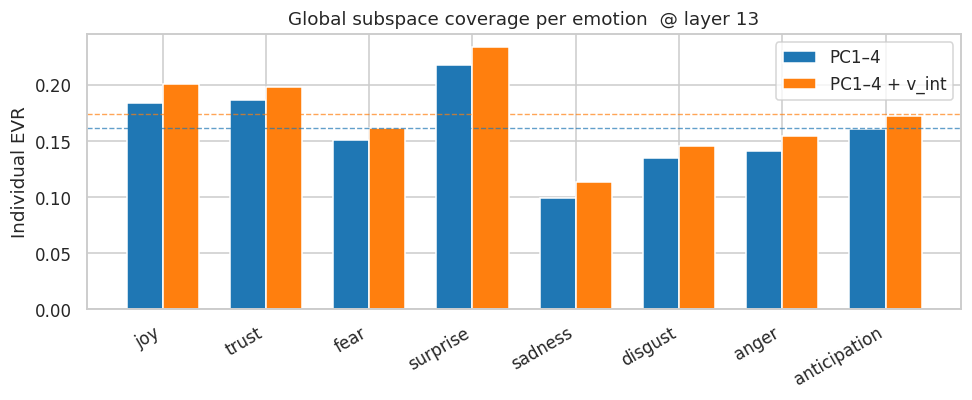

,evr_pc4,evr_pc4_plus_vint,total_var
emotion,,,
joy,0.184,0.201,91164.609
trust,0.187,0.198,92998.359
fear,0.151,0.162,83972.086
surprise,0.218,0.234,88260.781
sadness,0.099,0.114,76130.297
disgust,0.135,0.146,80082.203
anger,0.141,0.155,84810.500
anticipation,0.161,0.172,79311.734


In [12]:
per_emo_rows = []
for e_idx, emo in enumerate(EMOTION_ORDER):
    # (N_SUB * N_INT, D) – source-centered, grand-mean removed
    R_e   = R_L[:, e_idx, :, :].reshape(-1, D) - grand_mean
    tv    = float((R_e ** 2).sum())
    pv4   = float(((R_e @ PCs.T) ** 2).sum())
    pv_i  = pv4 + float(((R_e @ v_orth) ** 2).sum())
    per_emo_rows.append({
        'emotion':        emo,
        'evr_pc4':        pv4 / tv,
        'evr_pc4_plus_vint': pv_i / tv,
        'total_var':      tv,
    })
    del R_e

per_emo_df = pd.DataFrame(per_emo_rows).set_index('emotion').round(3)
per_emo_df.to_csv(OUT_DIR / 'per_emotion_reconstruction_evr.csv')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(EMOTION_ORDER))
w = 0.35
ax.bar(x - w/2, per_emo_df['evr_pc4'],            w, label='PC1–4',          color='#1f77b4')
ax.bar(x + w/2, per_emo_df['evr_pc4_plus_vint'],  w, label='PC1–4 + v_int',  color='#ff7f0e')
ax.axhline(evr_pc4, color='#1f77b4', ls='--', lw=0.9, alpha=0.7)
ax.axhline(evr_pi5, color='#ff7f0e', ls='--', lw=0.9, alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(EMOTION_ORDER, rotation=30, ha='right')
ax.set_ylabel('Individual EVR')
ax.set_title(f'Global subspace coverage per emotion  @ layer {STEER_LAYER}')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'per_emotion_evr.png', dpi=140)
plt.show()
per_emo_df


### §1c. Linear probe: emotion classification from PC projections

3-fold GroupKFold over `source_id` prevents leakage.
Balanced accuracy handles potential class imbalance (though this dataset is by design balanced).

| Input features | Dim |
|---|---|
| PC1–4 projections | 4 |
| PC1–4 + v\_int | 5 |
| Full 4096-D (300-source subsample) | 4096 |

In [15]:

# ── Build projection feature matrices in chunks (avoids 1 GB centred array) ──
n_total = N_SUB * N_EMO * N_INT
X_pc4   = np.empty((n_total, K_PCS), dtype=np.float32)
X_pi5   = np.empty((n_total, K_PCS + 1), dtype=np.float32)

for s0 in range(0, N_SUB, CHUNK):
    s1    = min(s0 + CHUNK, N_SUB)
    chunk = (R_L[s0:s1].reshape(-1, D) - grand_mean).astype(np.float32)
    rows  = slice(s0 * N_EMO * N_INT, s1 * N_EMO * N_INT)
    c_pc  = chunk @ PCs.T                              # (n, K_PCS)
    X_pc4[rows] = c_pc
    X_pi5[rows] = np.column_stack([c_pc, chunk @ v_orth])
    del chunk, c_pc

# Labels and groups
y_emo  = np.tile(np.repeat(np.arange(N_EMO), N_INT), N_SUB)
y_int  = np.tile(np.arange(N_INT), N_SUB * N_EMO)
groups = np.repeat(np.arange(N_SUB), N_EMO * N_INT)

# Full-4096D subsample: use FULL_D_NSRC sources so the array stays manageable
rng2 = np.random.default_rng(SEED + 1)
fd_src = np.sort(rng2.choice(N_SUB, size=FULL_D_NSRC, replace=False))
X_full        = (R_L[fd_src].reshape(-1, D) - grand_mean).astype(np.float32)
y_emo_full    = np.tile(np.repeat(np.arange(N_EMO), N_INT), FULL_D_NSRC)
y_int_full    = np.tile(np.arange(N_INT), FULL_D_NSRC * N_EMO)
groups_full   = np.repeat(np.arange(FULL_D_NSRC), N_EMO * N_INT)

print(f'Feature matrix sizes:')
print(f'  X_pc4  {X_pc4.shape}  {X_pc4.nbytes/1e6:.0f} MB')
print(f'  X_pi5  {X_pi5.shape}')
print(f'  X_full {X_full.shape}  {X_full.nbytes/1e6:.0f} MB  ({FULL_D_NSRC} sources)')


def cv_bacc(X: np.ndarray, y: np.ndarray, grp: np.ndarray, C: float = 0.1) -> float:
    """Balanced accuracy via 3-fold GroupKFold with LogisticRegression."""
    gkf   = GroupKFold(n_splits=min(3, len(np.unique(grp))))
    clf   = LogisticRegression(C=C, max_iter=1000, solver='saga', n_jobs=-1)
    preds = np.zeros_like(y)
    for tr, te in gkf.split(X, y, grp):
        clf.fit(X[tr], y[tr])
        preds[te] = clf.predict(X[te])
    return float(balanced_accuracy_score(y, preds))


print('\nEmotion classification (balanced accuracy):')
t0 = time.time()
bacc_emo_pc4  = cv_bacc(X_pc4,  y_emo,      groups)
print(f'  PC1–4:          {bacc_emo_pc4:.3f}  ({time.time()-t0:.1f}s)')
bacc_emo_pi5  = cv_bacc(X_pi5,  y_emo,      groups)
print(f'  PC1–4 + v_int:  {bacc_emo_pi5:.3f}  ({time.time()-t0:.1f}s)')
bacc_emo_full = cv_bacc(X_full, y_emo_full, groups_full)
print(f'  Full 4096-D:    {bacc_emo_full:.3f}  ({time.time()-t0:.1f}s)')
print(f'  Chance:         {1/N_EMO:.3f}')


Feature matrix sizes:
  X_pc4  (60000, 4)  1 MB
  X_pi5  (60000, 5)
  X_full (7200, 4096)  118 MB  (300 sources)

Emotion classification (balanced accuracy):
  PC1–4:          0.703  (0.3s)
  PC1–4 + v_int:  0.730  (0.5s)
  Full 4096-D:    0.886  (16.3s)
  Chance:         0.125


### §1d. Linear probe: intensity classification from PC projections

Same setup but predicting `low / medium / high` intensity.
`v_int` is the dedicated intensity direction — does adding it actually help?

Intensity classification (balanced accuracy):
  PC1–4:          0.332  (8.6s)
  PC1–4 + v_int:  0.333  (17.9s)
  Full 4096-D:    0.329  (423.1s)
  Chance:         0.333


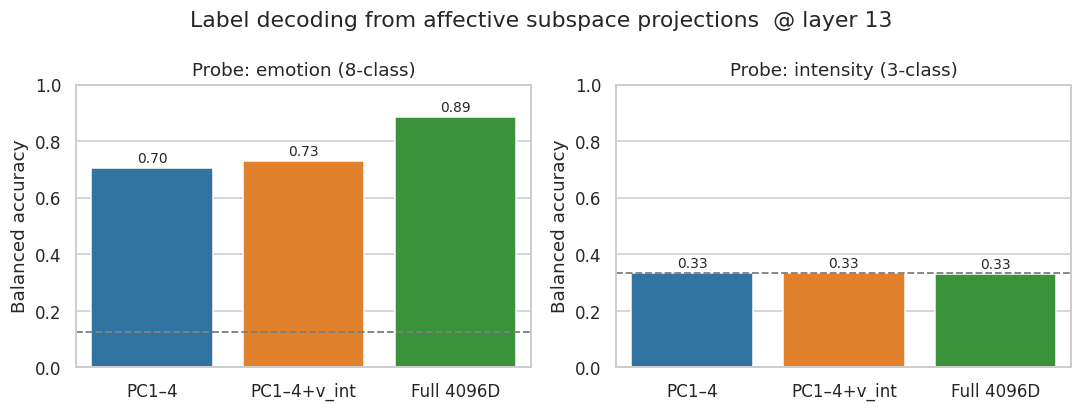

,task,subspace,bacc
0,emotion (8-class),PC1–4,0.703267
1,emotion (8-class),PC1–4+v_int,0.729883
2,emotion (8-class),Full 4096D,0.885972
3,intensity (3-class),PC1–4,0.332117
4,intensity (3-class),PC1–4+v_int,0.333333
5,intensity (3-class),Full 4096D,0.329306


In [16]:
print('Intensity classification (balanced accuracy):')
t0 = time.time()
bacc_int_pc4  = cv_bacc(X_pc4,  y_int,      groups)
print(f'  PC1–4:          {bacc_int_pc4:.3f}  ({time.time()-t0:.1f}s)')
bacc_int_pi5  = cv_bacc(X_pi5,  y_int,      groups)
print(f'  PC1–4 + v_int:  {bacc_int_pi5:.3f}  ({time.time()-t0:.1f}s)')
bacc_int_full = cv_bacc(X_full, y_int_full, groups_full)
print(f'  Full 4096-D:    {bacc_int_full:.3f}  ({time.time()-t0:.1f}s)')
print(f'  Chance:         {1/N_INT:.3f}')

# ── Visualise probe comparison ────────────────────────────────────────────────
probe_summary = pd.DataFrame([
    {'task': 'emotion (8-class)', 'subspace': 'PC1–4',      'bacc': bacc_emo_pc4},
    {'task': 'emotion (8-class)', 'subspace': 'PC1–4+v_int','bacc': bacc_emo_pi5},
    {'task': 'emotion (8-class)', 'subspace': 'Full 4096D', 'bacc': bacc_emo_full},
    {'task': 'intensity (3-class)','subspace': 'PC1–4',     'bacc': bacc_int_pc4},
    {'task': 'intensity (3-class)','subspace': 'PC1–4+v_int','bacc': bacc_int_pi5},
    {'task': 'intensity (3-class)','subspace': 'Full 4096D','bacc': bacc_int_full},
])
chance = {
    'emotion (8-class)':   1 / N_EMO,
    'intensity (3-class)': 1 / N_INT,
}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=False)
palette = {'PC1–4': '#1f77b4', 'PC1–4+v_int': '#ff7f0e', 'Full 4096D': '#2ca02c'}
for ax, task in zip(axes, ['emotion (8-class)', 'intensity (3-class)']):
    sub = probe_summary[probe_summary['task'] == task]
    sns.barplot(data=sub, x='subspace', y='bacc', hue='subspace',
                palette=palette, ax=ax, legend=False)
    ax.axhline(chance[task], color='grey', ls='--', lw=1.2, label='chance')
    ax.set_title(f'Probe: {task}')
    ax.set_xlabel('')
    ax.set_ylabel('Balanced accuracy')
    ax.set_ylim(0, 1)
    for patch, val in zip(ax.patches, sub['bacc']):
        ax.text(patch.get_x() + patch.get_width() / 2, val + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
fig.suptitle(f'Label decoding from affective subspace projections  @ layer {STEER_LAYER}')
fig.tight_layout()
fig.savefig(OUT_DIR / 'probe_accuracy_comparison.png', dpi=140)
plt.show()

probe_summary.to_csv(OUT_DIR / 'probe_accuracy_summary.csv', index=False)
probe_summary


### §1e. Predict judge continuous attributes from PC projections

If prior judge scores from `affective_subspace_interpretation.ipynb` exist
(`judge_scores.parquet`), we match each text to its PC projection and run a
RidgeCV regression to compare R² across subspaces.

Matched 224 judge samples to PC projections.


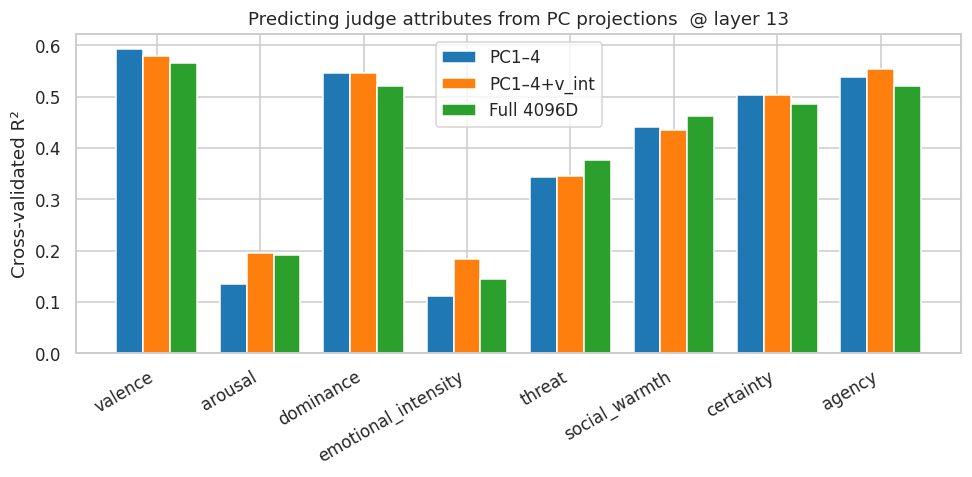

,attr,R2_PC4,R2_PC4_vint,R2_full
0,valence,0.593,0.578,0.566
1,arousal,0.136,0.196,0.192
2,dominance,0.546,0.547,0.521
3,emotional_intensity,0.111,0.183,0.145
4,threat,0.343,0.345,0.377
5,social_warmth,0.440,0.436,0.463
6,certainty,0.504,0.503,0.485
7,agency,0.539,0.553,0.521


In [17]:
JUDGE_ATTRS = ['valence', 'arousal', 'dominance', 'emotional_intensity',
               'threat', 'social_warmth', 'certainty', 'agency']

judge_parquet = PREV_DIR / 'judge_scores.parquet'
JUDGE_PRED_DF = None

if judge_parquet.exists():
    jdf = pd.read_parquet(judge_parquet)
    # Build lookup once (O(N_SUB)) instead of rebuilding a set per row.
    sid_to_local = {sid: i for i, sid in enumerate(SRC_ID_SUB)}

    # Match each judged sample to its PC projection
    # jdf has columns: source_id, emotion, intensity, [JUDGE_ATTRS]
    pc_rows = []
    for _, row in jdf.iterrows():
        sid, emo, lvl = row['source_id'], row['emotion'], row['intensity']
        s_idx_local = sid_to_local.get(sid)
        if s_idx_local is None:
            continue
        r_vec = R_L[s_idx_local, EMO_POS[emo], INT_POS[lvl]] - grand_mean
        pc_rows.append({
            'source_id': sid, 'emotion': emo, 'intensity': lvl,
            **{f'PC{k+1}': float(r_vec @ PCs[k]) for k in range(K_PCS)},
            'v_int_coord': float(r_vec @ v_orth),
            **{a: float(row[a]) for a in JUDGE_ATTRS if a in row},
        })

    jpc = pd.DataFrame(pc_rows)
    print(f'Matched {len(jpc)} judge samples to PC projections.')

    def ridge_r2_cv(X: np.ndarray, y: np.ndarray, grp: np.ndarray) -> float:
        """Cross-validated R² (RidgeCV, GroupKFold=3)."""
        if np.std(y) < 1e-9 or len(np.unique(grp)) < 3:
            return float('nan')
        gkf   = GroupKFold(n_splits=min(3, len(np.unique(grp))))
        preds = np.zeros_like(y, dtype=float)
        for tr, te in gkf.split(X, y, grp):
            m = RidgeCV(alphas=[0.1, 1, 10, 100])
            m.fit(X[tr], y[tr])
            preds[te] = m.predict(X[te])
        ss_res = ((y - preds) ** 2).sum()
        ss_tot = ((y - y.mean()) ** 2).sum()
        return float(1 - ss_res / max(ss_tot, 1e-12))

    grp_j = jpc['source_id'].map({s: i for i, s in enumerate(jpc['source_id'].unique())}).to_numpy()
    X_pc4_j = jpc[[f'PC{k+1}' for k in range(K_PCS)]].to_numpy(dtype=float)
    X_pi5_j = np.column_stack([X_pc4_j, jpc['v_int_coord'].to_numpy()])

    # Full-D activation for judged samples
    X_full_j = np.array([
        R_L[sid_to_local[row.source_id], EMO_POS[row.emotion], INT_POS[row.intensity]] - grand_mean
        for _, row in jpc.iterrows()
    ], dtype=np.float32)

    judge_pred_rows = []
    for attr in JUDGE_ATTRS:
        if attr not in jpc.columns:
            continue
        y = jpc[attr].to_numpy(dtype=float)
        r2_pc4  = ridge_r2_cv(X_pc4_j, y, grp_j)
        r2_pi5  = ridge_r2_cv(X_pi5_j, y, grp_j)
        r2_full = ridge_r2_cv(X_full_j, y, grp_j)
        judge_pred_rows.append({'attr': attr,
                                'R2_PC4': r2_pc4, 'R2_PC4_vint': r2_pi5,
                                'R2_full': r2_full})

    JUDGE_PRED_DF = pd.DataFrame(judge_pred_rows)
    JUDGE_PRED_DF.to_csv(OUT_DIR / 'judge_attr_prediction_r2.csv', index=False)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(judge_pred_rows))
    w = 0.26
    ax.bar(x - w,   JUDGE_PRED_DF['R2_PC4'],      w, label='PC1–4',       color='#1f77b4')
    ax.bar(x,       JUDGE_PRED_DF['R2_PC4_vint'], w, label='PC1–4+v_int', color='#ff7f0e')
    ax.bar(x + w,   JUDGE_PRED_DF['R2_full'],     w, label='Full 4096D',  color='#2ca02c')
    ax.set_xticks(x); ax.set_xticklabels(JUDGE_PRED_DF['attr'], rotation=30, ha='right')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Cross-validated R²')
    ax.set_title(f'Predicting judge attributes from PC projections  @ layer {STEER_LAYER}')
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'judge_attr_prediction_r2.png', dpi=140)
    plt.show()
    display(JUDGE_PRED_DF.round(3))
else:
    print(f'Judge scores not found at {judge_parquet}.')
    print('Run affective_subspace_interpretation.ipynb first, or set DRY_RUN=True there.')


### §1f. Summary of Analysis 1

In [18]:
coverage_summary = {
    'layer': STEER_LAYER,
    'centroid_evr_pc4':      round(centroid_evr, 4),
    'individual_evr_pc4':    round(evr_pc4, 4),
    'individual_evr_pc4_vint': round(evr_pi5, 4),
    'probe_emotion_bacc': {
        'PC4':      round(bacc_emo_pc4,  4),
        'PC4_vint': round(bacc_emo_pi5,  4),
        'full_D':   round(bacc_emo_full, 4),
        'chance':   round(1 / N_EMO,     4),
    },
    'probe_intensity_bacc': {
        'PC4':      round(bacc_int_pc4,  4),
        'PC4_vint': round(bacc_int_pi5,  4),
        'full_D':   round(bacc_int_full, 4),
        'chance':   round(1 / N_INT,     4),
    },
    'per_emotion_evr': per_emo_df[['evr_pc4', 'evr_pc4_plus_vint']].round(4).to_dict(orient='index'),
}
if JUDGE_PRED_DF is not None:
    coverage_summary['judge_attr_r2'] = JUDGE_PRED_DF.set_index('attr').round(4).to_dict(orient='index')

print('=== Analysis 1: Coverage Summary ===')
for k, v in coverage_summary.items():
    if isinstance(v, dict):
        print(f'  {k}:')
        for kk, vv in v.items():
            print(f'    {kk}: {vv}')
    else:
        print(f'  {k}: {v}')


=== Analysis 1: Coverage Summary ===
  layer: 13
  centroid_evr_pc4: 0.892
  individual_evr_pc4: 0.1613
  individual_evr_pc4_vint: 0.1746
  probe_emotion_bacc:
    PC4: 0.7033
    PC4_vint: 0.7299
    full_D: 0.886
    chance: 0.125
  probe_intensity_bacc:
    PC4: 0.3321
    PC4_vint: 0.3333
    full_D: 0.3293
    chance: 0.3333
  per_emotion_evr:
    joy: {'evr_pc4': 0.184, 'evr_pc4_plus_vint': 0.201}
    trust: {'evr_pc4': 0.187, 'evr_pc4_plus_vint': 0.198}
    fear: {'evr_pc4': 0.151, 'evr_pc4_plus_vint': 0.162}
    surprise: {'evr_pc4': 0.218, 'evr_pc4_plus_vint': 0.234}
    sadness: {'evr_pc4': 0.099, 'evr_pc4_plus_vint': 0.114}
    disgust: {'evr_pc4': 0.135, 'evr_pc4_plus_vint': 0.146}
    anger: {'evr_pc4': 0.141, 'evr_pc4_plus_vint': 0.155}
    anticipation: {'evr_pc4': 0.161, 'evr_pc4_plus_vint': 0.172}
  judge_attr_r2:
    valence: {'R2_PC4': 0.5929, 'R2_PC4_vint': 0.5784, 'R2_full': 0.5663}
    arousal: {'R2_PC4': 0.136, 'R2_PC4_vint': 0.1956, 'R2_full': 0.1916}
    domina

---
## Analysis 2 — Emotion-wise Local PCA

For each of the 8 emotions we:
1. Extract source-centered activations `R_e = R[:,e,:,:] − C_e` where `C_e` is the emotion centroid.
2. Run **randomized truncated SVD** (top-`K_LOCAL=6` PCs) — avoids full SVD of (7500 × 4096).
3. Compute per-PC EVR and **participation ratio** (effective dimensionality).
4. Visualize how `low / medium / high` intensity distributes along local PC1.
5. Compute cosine alignment of local PCs with global PCs and `v_int`.
6. Print extreme-end examples so axes can be labeled by inspection.

### §2a. Per-emotion randomized SVD + EVR table

In [19]:
LOCAL_PCA: dict[str, dict] = {}   # emo -> dict with PCs, S, projections, etc.
local_evr_rows = []

# Intensity label array for (N_SUB * N_INT,) samples within one emotion
int_labels = np.tile(np.arange(N_INT), N_SUB)   # [0,1,2, 0,1,2, ...]
# Source group array for GroupKFold
src_groups_local = np.repeat(np.arange(N_SUB), N_INT)

for e_idx, emo in enumerate(EMOTION_ORDER):
    C_e = basis['C'][e_idx]                          # (D,) emotion centroid
    R_e = R_L[:, e_idx, :, :].reshape(-1, D) - C_e  # (N_SUB*N_INT, D) ~117 MB

    # Frobenius norm for EVR denominator.
    # np.einsum avoids creating a float64 copy of R_e: sums R_e²
    # accumulating in float64 without materialising a full float64 array.
    total_var_e = float(np.einsum('ij,ij->', R_e, R_e, dtype=np.float64))

    # Randomized truncated SVD (much faster than full SVD for (7500, 4096))
    _, S_loc, Vt_loc = randomized_svd(
        R_e.astype(np.float64), n_components=K_LOCAL,
        random_state=SEED, n_iter=4
    )
    PCs_loc = Vt_loc.astype(np.float32)              # (K_LOCAL, D) approx orthonormal

    # Projections for each sample
    proj_loc = R_e @ PCs_loc.T                        # (N_SUB*N_INT, K_LOCAL)

    # EVR per PC and cumulative
    var_k  = (S_loc ** 2)
    evr_k  = var_k / total_var_e
    pr_val = participation_ratio(S_loc)

    LOCAL_PCA[emo] = dict(
        PCs=PCs_loc, S=S_loc, evr_k=evr_k,
        proj=proj_loc.astype(np.float32),
        total_var=total_var_e, pr=pr_val,
        int_labels=int_labels.copy(),
    )

    row = {'emotion': emo, 'participation_ratio': round(pr_val, 2)}
    for k in range(K_LOCAL):
        row[f'EVR_PC{k+1}'] = round(float(evr_k[k]), 4)
    row['EVR_cum4'] = round(float(evr_k[:4].sum()), 4)
    row['EVR_cum6'] = round(float(evr_k[:6].sum()), 4)
    local_evr_rows.append(row)

    del R_e
    gc.collect()

local_evr_df = pd.DataFrame(local_evr_rows).set_index('emotion')
local_evr_df.to_csv(OUT_DIR / 'local_pca_evr.csv')
print('Local PCA EVR and participation ratio:')
display(local_evr_df.round(3))


Local PCA EVR and participation ratio:


,participation_ratio,EVR_PC1,EVR_PC2,EVR_PC3,EVR_PC4,EVR_PC5,EVR_PC6,EVR_cum4,EVR_cum6
emotion,,,,,,,,,
joy,3.49,0.141,0.048,0.038,0.031,0.023,0.016,0.259,0.298
trust,4.16,0.097,0.046,0.033,0.028,0.020,0.018,0.203,0.242
fear,4.51,0.085,0.043,0.035,0.025,0.022,0.021,0.188,0.232
surprise,5.12,0.070,0.060,0.045,0.040,0.023,0.021,0.215,0.259
sadness,4.45,0.085,0.042,0.035,0.025,0.023,0.019,0.187,0.228
disgust,4.62,0.082,0.041,0.035,0.024,0.023,0.022,0.182,0.227
anger,5.01,0.069,0.048,0.036,0.028,0.023,0.021,0.181,0.225
anticipation,4.77,0.074,0.057,0.033,0.028,0.022,0.020,0.192,0.234


### §2b. Scree plot and intensity distribution along local PC1

Two panels per emotion:
- **Left**: scree plot (per-PC EVR).
- **Right**: box / violin plot of local PC1 scores stratified by intensity level.

If `low < medium < high` along PC1, that PC encodes intensity *within* this emotion.

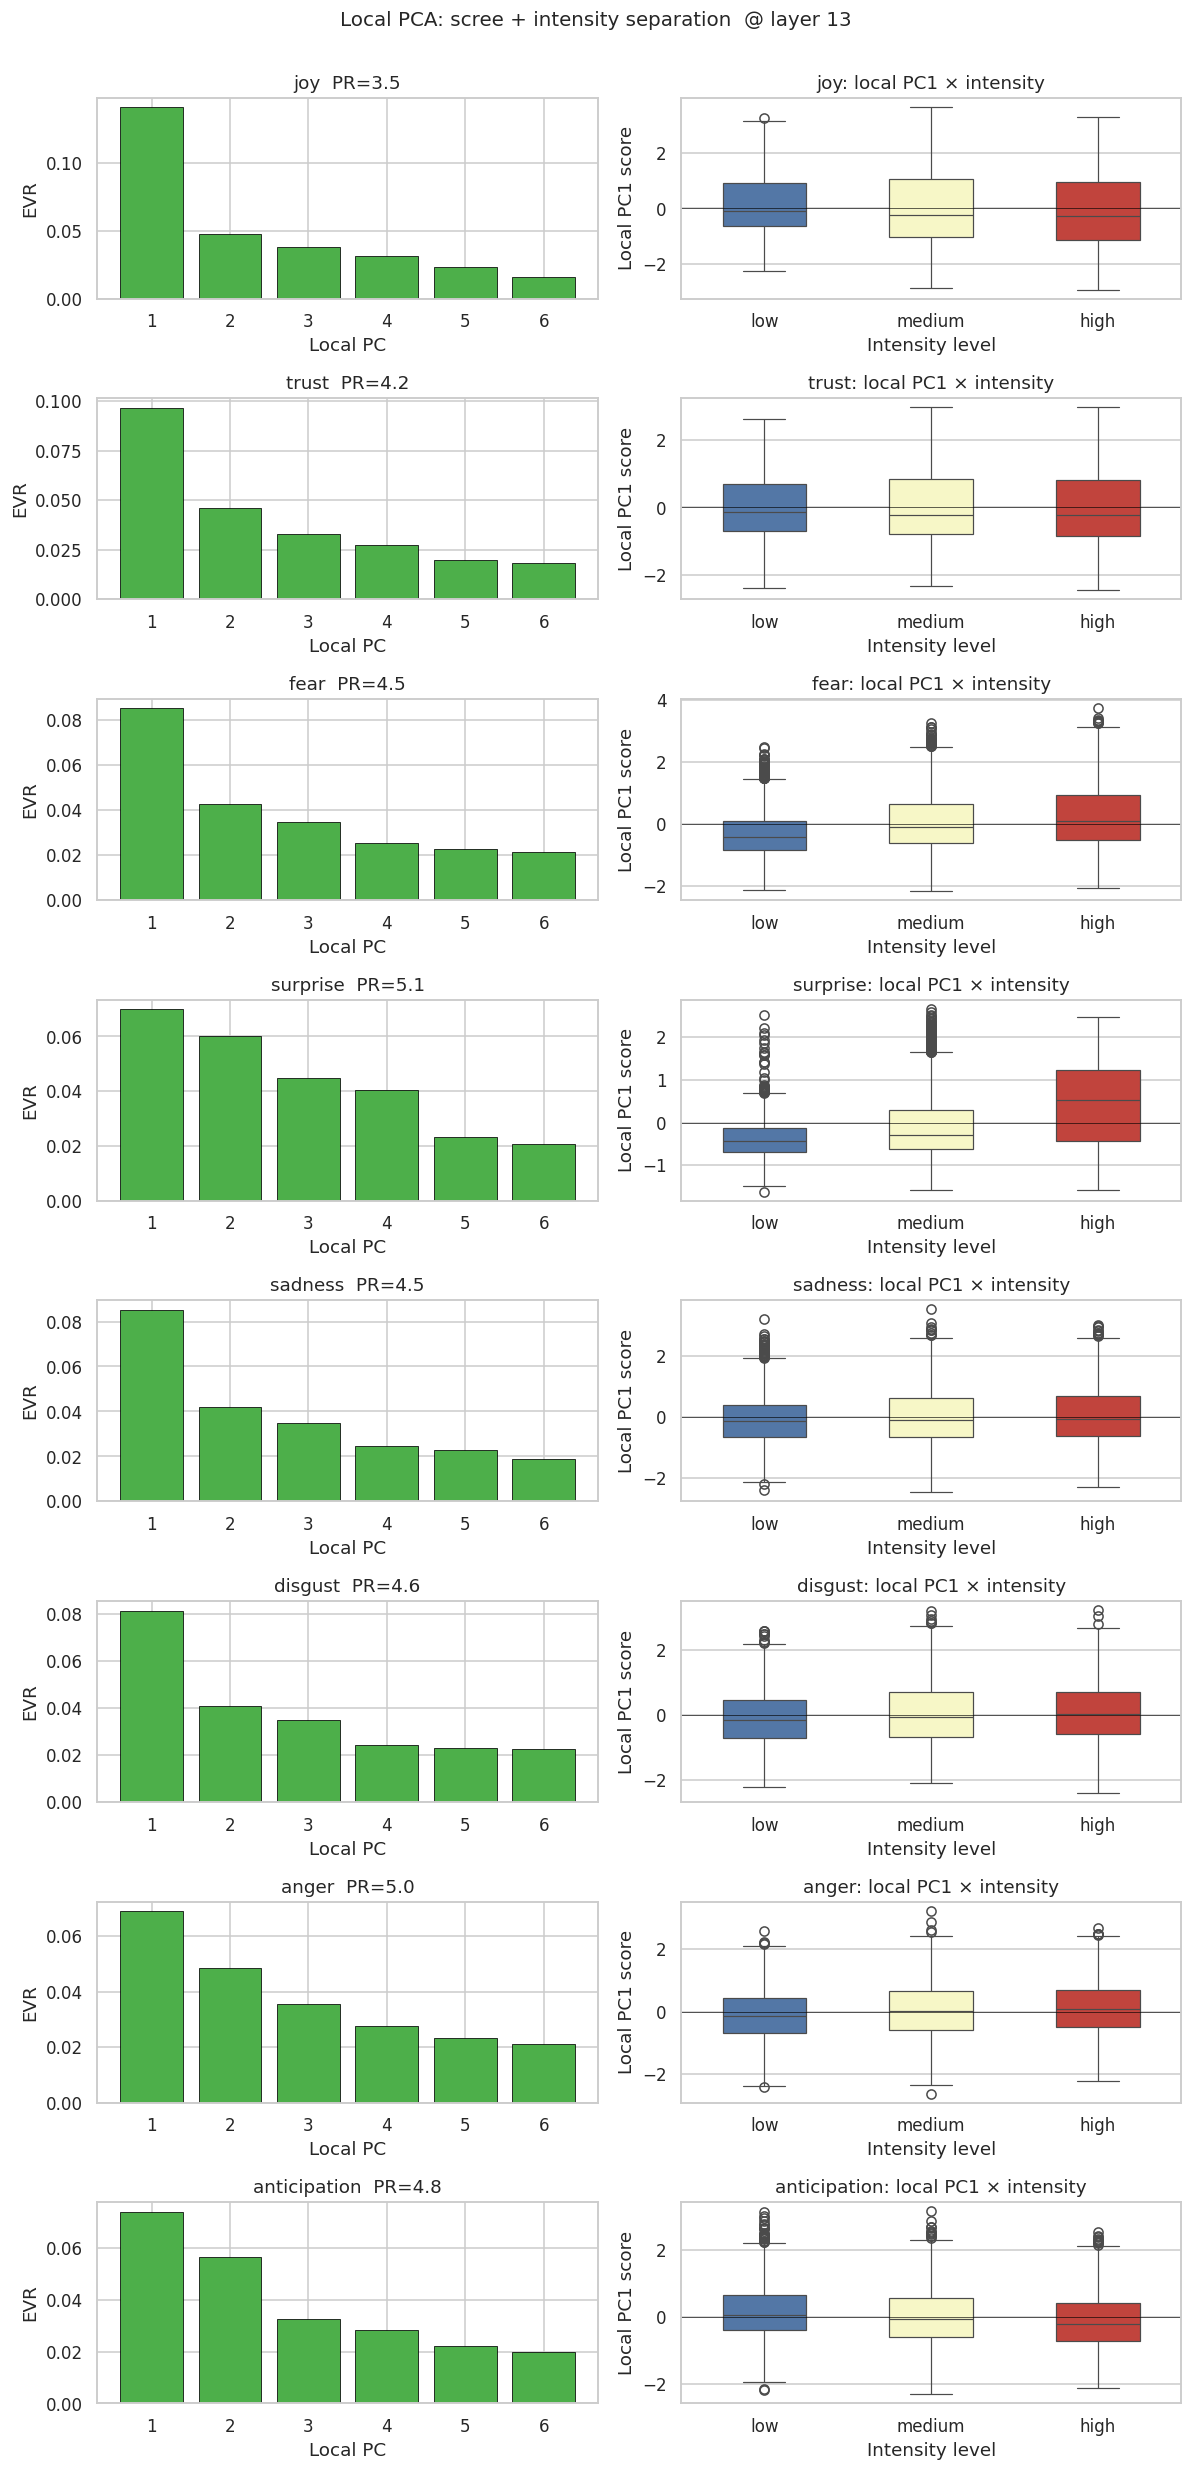

In [20]:
n_emo  = len(EMOTION_ORDER)
PALETTE_INT = {'low': '#4575b4', 'medium': '#ffffbf', 'high': '#d73027'}

fig, axes = plt.subplots(n_emo, 2, figsize=(11, 2.8 * n_emo))
for row_ax, emo in zip(axes, EMOTION_ORDER):
    lp = LOCAL_PCA[emo]
    evr_k = lp['evr_k']
    proj  = lp['proj']
    ints  = lp['int_labels']

    # Left: scree
    ax_scree = row_ax[0]
    ax_scree.bar(range(1, K_LOCAL + 1), evr_k[:K_LOCAL],
                 color='#4daf4a', edgecolor='k', linewidth=0.5)
    ax_scree.set_xlabel('Local PC'); ax_scree.set_ylabel('EVR')
    ax_scree.set_title(f'{emo}  PR={lp["pr"]:.1f}')
    ax_scree.set_xticks(range(1, K_LOCAL + 1))

    # Right: PC1 score by intensity
    ax_int = row_ax[1]
    pc1_scores = proj[:, 0]
    int_df = pd.DataFrame({'pc1': pc1_scores, 'intensity': [INTENSITY_ORDER[i] for i in ints]})
    sns.boxplot(data=int_df, x='intensity', y='pc1', order=INTENSITY_ORDER,
                palette=PALETTE_INT, width=0.5, ax=ax_int, linewidth=0.8)
    ax_int.axhline(0, color='k', lw=0.4)
    ax_int.set_title(f'{emo}: local PC1 × intensity')
    ax_int.set_xlabel('Intensity level'); ax_int.set_ylabel('Local PC1 score')

fig.suptitle(f'Local PCA: scree + intensity separation  @ layer {STEER_LAYER}',
             y=1.002, fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / 'local_pca_scree_and_intensity.png', dpi=130, bbox_inches='tight')
plt.show()


### §2c. PC1–PC2 scatter per emotion (intensity coloured)

2D scatter of local PC1 vs PC2 with intensity encoded as colour.
Helps see if the principal plane separates intensity or something else.

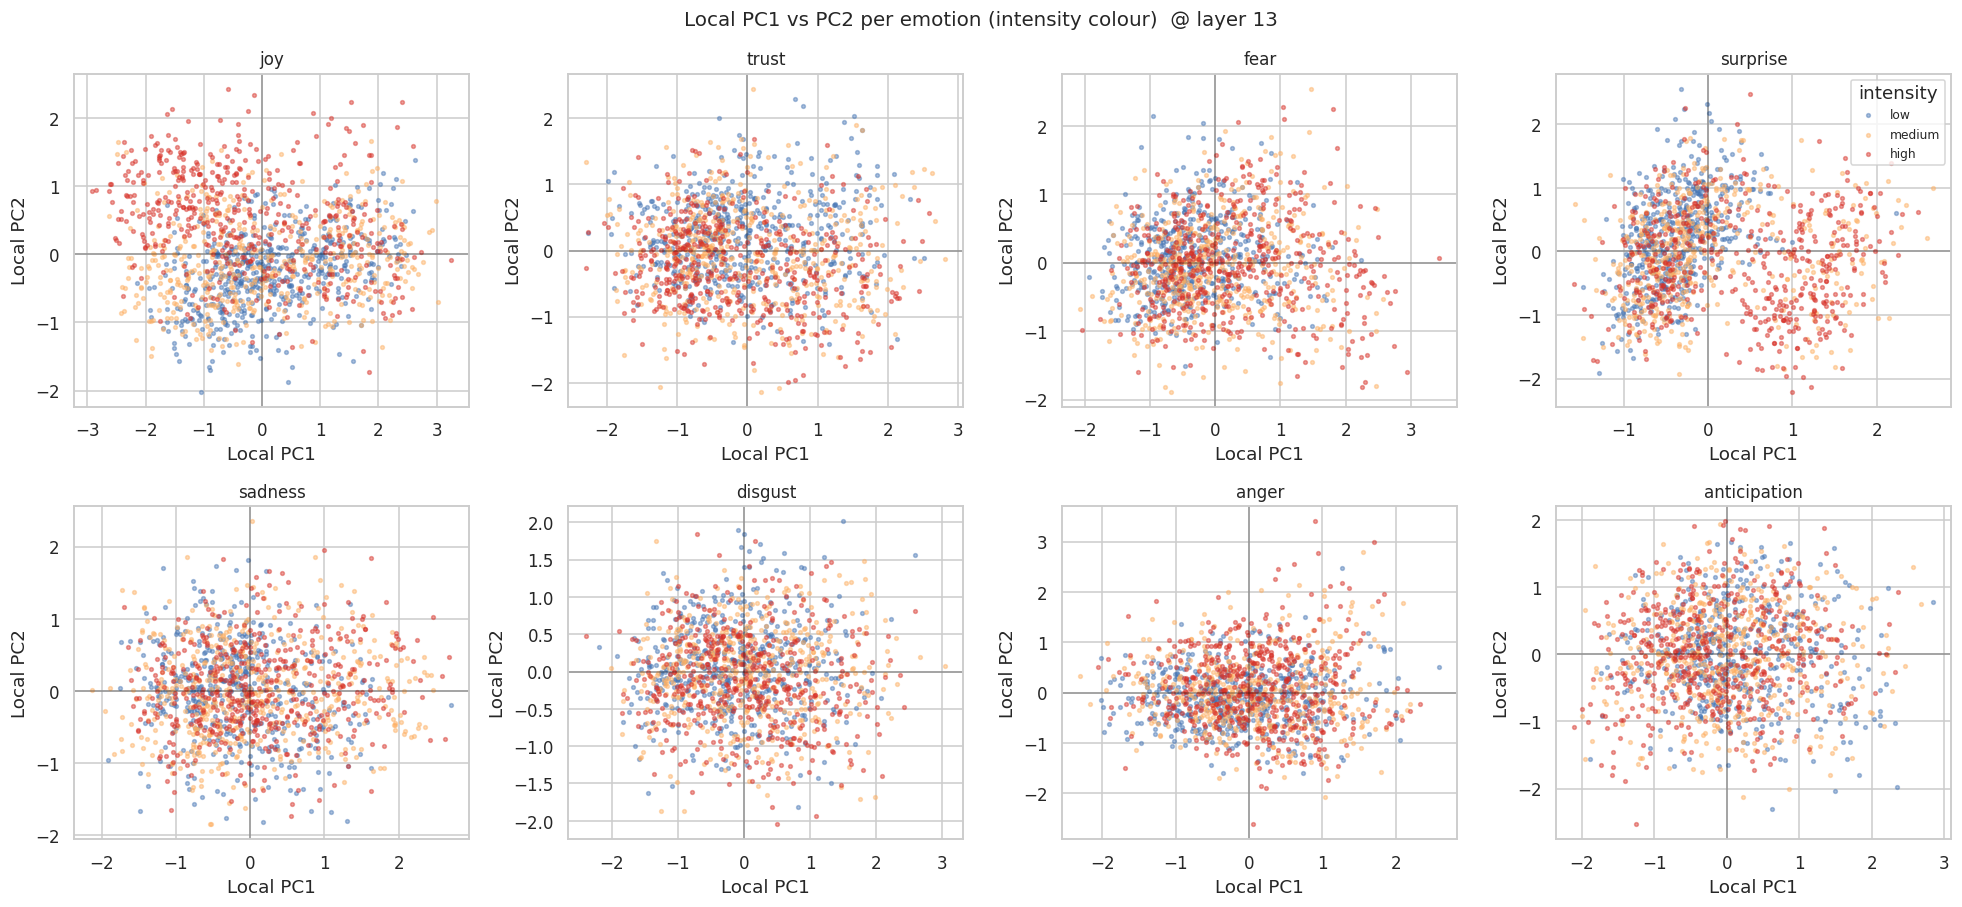

In [21]:
CMAP_INT = {0: '#4575b4', 1: '#fdae61', 2: '#d73027'}   # low / medium / high

ncols = 4
nrows = int(np.ceil(n_emo / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.2 * nrows))
axes_flat = axes.flatten()

rng_scatter = np.random.default_rng(SEED)
for ax, emo in zip(axes_flat, EMOTION_ORDER):
    lp   = LOCAL_PCA[emo]
    proj = lp['proj']
    ints = lp['int_labels']
    # Subsample for readability
    idx  = rng_scatter.choice(len(proj), size=min(1500, len(proj)), replace=False)
    for lvl_i, lvl_name in enumerate(INTENSITY_ORDER):
        mask = ints[idx] == lvl_i
        ax.scatter(proj[idx[mask], 0], proj[idx[mask], 1],
                   s=6, alpha=0.45, color=CMAP_INT[lvl_i], label=lvl_name)
    ax.axhline(0, color='k', lw=0.3); ax.axvline(0, color='k', lw=0.3)
    ax.set_title(emo, fontsize=11)
    ax.set_xlabel('Local PC1'); ax.set_ylabel('Local PC2')

axes_flat[ncols - 1].legend(title='intensity', loc='upper right', fontsize=8)
for ax in axes_flat[n_emo:]:
    ax.set_visible(False)
fig.suptitle(f'Local PC1 vs PC2 per emotion (intensity colour)  @ layer {STEER_LAYER}',
             fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / 'local_pca_pc12_scatter.png', dpi=130, bbox_inches='tight')
plt.show()


### §2d. Local PC alignment with the global basis

For each emotion and each local PC, compute:

$$\cos(\text{local\_PC}_k^{(e)},\; \text{global\_PC}_j) \quad \text{and} \quad \cos(\text{local\_PC}_k^{(e)},\; v_\text{int})$$

A high |cos| between local PC1 of *fear* and global PC1 suggests that *within fear*, the dominant
axis is the same valence/threat direction that separates emotions globally.
A high |cos| with `v_int` means the local axis is mostly intensity.

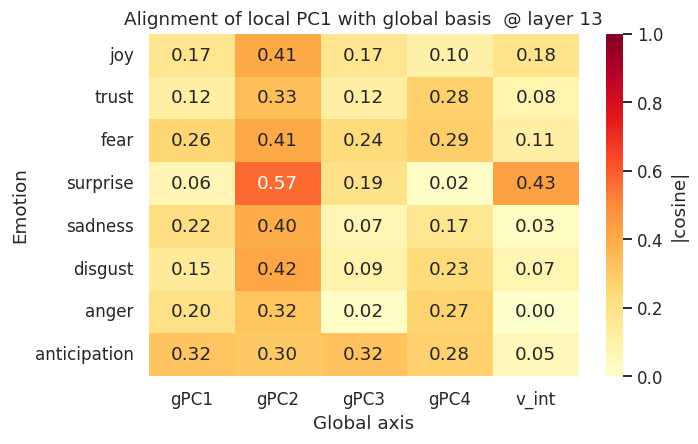


Max |cosine| with any global axis (local PC1/2/3):


local_pc,PC1,PC2,PC3
emotion,,,
anger,0.315,0.521,0.222
anticipation,0.323,0.527,0.335
disgust,0.419,0.380,0.197
fear,0.406,0.417,0.143
joy,0.405,0.522,0.438
sadness,0.402,0.411,0.207
surprise,0.569,0.318,0.256
trust,0.334,0.448,0.268


In [22]:
align_rows = []
for emo in EMOTION_ORDER:
    lp     = LOCAL_PCA[emo]
    PCs_l  = lp['PCs']                     # (K_LOCAL, D)
    for k in range(K_LOCAL):
        pc_l = PCs_l[k] / (np.linalg.norm(PCs_l[k]) + 1e-12)
        row  = {'emotion': emo, 'local_pc': f'PC{k+1}'}
        # Cosine with each global PC (take abs to ignore sign convention)
        for j in range(K_PCS):
            g = PCs[j] / (np.linalg.norm(PCs[j]) + 1e-12)
            row[f'cos_gPC{j+1}'] = round(float(abs(np.dot(pc_l, g))), 3)
        # Cosine with v_int
        row['cos_vint'] = round(float(abs(np.dot(pc_l, v_int))), 3)
        # Max alignment
        all_cos = [row[f'cos_gPC{j+1}'] for j in range(K_PCS)] + [row['cos_vint']]
        row['max_cos'] = round(max(all_cos), 3)
        row['best_match'] = (
            [f'gPC{j+1}' for j in range(K_PCS)] + ['v_int']
        )[np.argmax(all_cos)]
        align_rows.append(row)

ALIGN_DF = pd.DataFrame(align_rows)
ALIGN_DF.to_csv(OUT_DIR / 'local_global_alignment.csv', index=False)

# ── Heatmap: |cos(local PC1, global basis)| per emotion ─────────────────────
align_pc1 = ALIGN_DF[ALIGN_DF['local_pc'] == 'PC1'].set_index('emotion')
cos_cols   = [f'cos_gPC{j+1}' for j in range(K_PCS)] + ['cos_vint']
mat        = align_pc1[cos_cols].astype(float)
mat.columns = [f'gPC{j+1}' for j in range(K_PCS)] + ['v_int']

fig, ax = plt.subplots(figsize=(6.5, 4.2))
sns.heatmap(mat, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '|cosine|'})
ax.set_title(f'Alignment of local PC1 with global basis  @ layer {STEER_LAYER}')
ax.set_xlabel('Global axis'); ax.set_ylabel('Emotion')
fig.tight_layout()
fig.savefig(OUT_DIR / 'local_pc1_global_alignment.png', dpi=140)
plt.show()

# Also show top-3 local PCs
align_top3 = ALIGN_DF[ALIGN_DF['local_pc'].isin(['PC1', 'PC2', 'PC3'])]
pivot_max = align_top3.pivot_table(
    index='emotion', columns='local_pc', values='max_cos', aggfunc='first'
)
print('\nMax |cosine| with any global axis (local PC1/2/3):')
display(pivot_max.round(3))


### §2e. Extreme examples per emotion × local PC

For each emotion, print the top-`N_EX` positive and negative examples along local PC1 and PC2.
Reading these is the primary way to assign a semantic label to each local axis.

In [23]:
N_EX       = 5    # examples per pole per PC
SHOW_N_PCS = 2   # how many local PCs to show examples for

# For each (s_local, i) position in the flattened (N_SUB*N_INT,) vector,
# the source_id is SRC_ID_SUB[s_local // N_INT... wait, local index
# within each emotion: row index j maps to source j//N_INT, intensity j%N_INT

extreme_all = []

for emo in EMOTION_ORDER:
    lp   = LOCAL_PCA[emo]
    proj = lp['proj']           # (N_SUB * N_INT, K_LOCAL)

    print(f'\n{"="*72}')
    print(f'EMOTION: {emo.upper()}   PR={lp["pr"]:.2f}   EVR_cum4={lp["evr_k"][:4].sum():.3f}')
    print(f'  Alignment: best_match(PC1) = '
          f'{ALIGN_DF[(ALIGN_DF.emotion==emo) & (ALIGN_DF.local_pc=="PC1")]["best_match"].values[0]}'
          f'  (cos={ALIGN_DF[(ALIGN_DF.emotion==emo) & (ALIGN_DF.local_pc=="PC1")]["max_cos"].values[0]:.2f})')
    print('='*72)

    for pc_k in range(SHOW_N_PCS):
        scores = proj[:, pc_k]
        top_pos = np.argsort(scores)[-N_EX:][::-1]
        top_neg = np.argsort(scores)[:N_EX]

        pc_evr = lp['evr_k'][pc_k]
        pc_cos = ALIGN_DF[
            (ALIGN_DF.emotion == emo) & (ALIGN_DF.local_pc == f'PC{pc_k+1}')
        ][['cos_gPC1', 'cos_gPC2', 'cos_gPC3', 'cos_gPC4', 'cos_vint']].values[0]
        align_str = '  '.join(
            f'{n}={v:.2f}' for n, v in zip(['gPC1','gPC2','gPC3','gPC4','vint'], pc_cos)
        )
        print(f'\n  Local PC{pc_k+1}  EVR={pc_evr:.4f}  |cos|: {align_str}')

        for pole, indices in [('+', top_pos), ('−', top_neg)]:
            print(f'  {"─"*68}')
            print(f'  Pole {pole}:')
            for j in indices:
                s_local = j // N_INT
                i_local = j % N_INT
                src_id  = SRC_ID_SUB[s_local]
                lvl     = INTENSITY_ORDER[i_local]
                text    = REGISTRY.get((src_id, emo, lvl), '<missing>')
                snippet = text[:175].replace('\n', ' ')
                print(f'    [{scores[j]:+.2f}|{lvl:<6}] {snippet}')

                extreme_all.append({
                    'emotion': emo, 'local_pc': pc_k + 1, 'pole': pole,
                    'score': float(scores[j]), 'intensity': lvl,
                    'source_id': src_id, 'text': text,
                })

extreme_df = pd.DataFrame(extreme_all)
extreme_df.to_csv(OUT_DIR / 'local_pca_extremes.csv', index=False)
print(f'\nSaved {len(extreme_df)} extreme examples → {OUT_DIR}/local_pca_extremes.csv')



EMOTION: JOY   PR=3.49   EVR_cum4=0.259
  Alignment: best_match(PC1) = gPC2  (cos=0.41)

  Local PC1  EVR=0.1414  |cos|: gPC1=0.17  gPC2=0.41  gPC3=0.17  gPC4=0.10  vint=0.18
  ────────────────────────────────────────────────────────────────────
  Pole +:
    [+3.66|medium] Even though I got lost at the county fair and couldn't find my mom, I ended up enjoying some of the rides while waiting.
    [+3.60|medium] Even though my neighbor lets their dog go in my yard, it gave me a chance to enjoy some fresh air and sunshine today.
    [+3.30|high  ] Even though my coworker doesn't stop chatting and asking questions, sometimes I find myself laughing at the ridiculous things he says when I'm really swamped.
    [+3.26|low   ] My friend kept whistling, but I guess it didn’t ruin the whole time.
    [+3.25|high  ] The garbage collector didn't get my trash today, but honestly, at least now I have a little extra time to sort through it and maybe recycle more.
  ─────────────────────────────────

### §2f. Cross-emotion comparison: dimensionality and intensity alignment

Two summary figures:
1. **Participation ratio** bar chart — which emotions have low-dimensional (PR ≈ 1) vs
   diffuse (high PR) internal structure?
2. **Heatmap** of |cos(local PC1, global axis)| across all emotions — shows which
   emotions are "aligned" with the global valence/arousal/etc. axes.

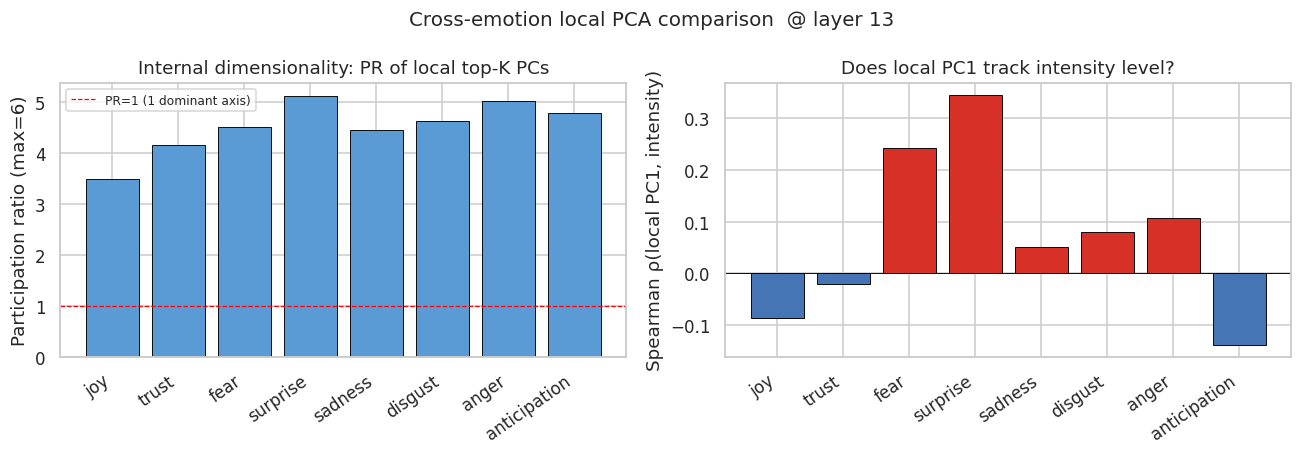

,participation_ratio,EVR_cum4,EVR_cum6,spearman_rho_pc1_int
emotion,,,,
joy,3.49,0.259,0.298,-0.086
trust,4.16,0.203,0.242,-0.021
fear,4.51,0.188,0.232,0.243
surprise,5.12,0.215,0.259,0.344
sadness,4.45,0.187,0.228,0.051
disgust,4.62,0.182,0.227,0.080
anger,5.01,0.181,0.225,0.108
anticipation,4.77,0.192,0.234,-0.137


In [24]:
# ── Intensity Spearman ρ for local PC1: does it monotonically track intensity? ─
int_rho_rows = []
for emo in EMOTION_ORDER:
    lp   = LOCAL_PCA[emo]
    pc1_scores = lp['proj'][:, 0]
    int_numeric = lp['int_labels'].astype(float)   # 0=low, 1=medium, 2=high
    rho = float(stats.spearmanr(pc1_scores, int_numeric).statistic)
    int_rho_rows.append({'emotion': emo, 'spearman_rho_pc1_int': rho})

int_rho_df = pd.DataFrame(int_rho_rows).set_index('emotion')
int_rho_df.to_csv(OUT_DIR / 'local_pc1_intensity_spearman.csv')

# ── Figure 1: Participation ratio + intensity ρ side by side ─────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# Participation ratio
pr_vals = [LOCAL_PCA[e]['pr'] for e in EMOTION_ORDER]
colors_pr = [f'#{int(255*(1-v/K_LOCAL)):02x}{int(255*v/K_LOCAL):02x}80'
             for v in pr_vals]  # blue=low PR / green=high PR
ax1.bar(EMOTION_ORDER, pr_vals, color='#5b9bd5', edgecolor='k', linewidth=0.6)
ax1.set_xticks(range(len(EMOTION_ORDER))); ax1.set_xticklabels(EMOTION_ORDER, rotation=35, ha='right')
ax1.set_ylabel(f'Participation ratio (max={K_LOCAL})')
ax1.set_title('Internal dimensionality: PR of local top-K PCs')
ax1.axhline(1, color='r', ls='--', lw=0.8, label='PR=1 (1 dominant axis)')
ax1.legend(fontsize=8)

# Intensity Spearman
rho_vals = [float(int_rho_df.loc[e, 'spearman_rho_pc1_int']) for e in EMOTION_ORDER]
color_rho = ['#d73027' if r > 0 else '#4575b4' for r in rho_vals]
ax2.bar(EMOTION_ORDER, rho_vals, color=color_rho, edgecolor='k', linewidth=0.6)
ax2.axhline(0, color='k', lw=0.6)
ax2.set_xticks(range(len(EMOTION_ORDER))); ax2.set_xticklabels(EMOTION_ORDER, rotation=35, ha='right')
ax2.set_ylabel('Spearman ρ(local PC1, intensity)')
ax2.set_title('Does local PC1 track intensity level?')

fig.suptitle(f'Cross-emotion local PCA comparison  @ layer {STEER_LAYER}', fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / 'cross_emotion_local_pca_summary.png', dpi=140)
plt.show()

pd.concat([local_evr_df[['participation_ratio', 'EVR_cum4', 'EVR_cum6']], int_rho_df], axis=1).round(3)


---
## 3. Headline metrics at auxiliary layers (10, 16)

For each auxiliary layer we repeat the headline metrics using the **same** source subsample and
the **layer-specific** global basis (PC1–4 rebuilt from that layer's centroids).

Metrics reported:
- Centroid EVR (PC1–4)
- Individual EVR (PC1–4) and (PC1–4 + v_int)
- Emotion probe balanced accuracy (PC1–4)
- Per-emotion local PC1 intensity Spearman ρ (just the mean over emotions)

In [25]:
# Free R_L from primary layer before loading aux layers.
del R_L
gc.collect()

layer_comparison_rows = []

# Include layer 13 results already computed
layer_comparison_rows.append({
    'layer':          STEER_LAYER,
    'centroid_evr4':  round(centroid_evr, 4),
    'indiv_evr_pc4':  round(evr_pc4, 4),
    'indiv_evr_pc4_vint': round(evr_pi5, 4),
    'emo_probe_bacc_pc4': round(bacc_emo_pc4, 4),
    'int_probe_bacc_pc4': round(bacc_int_pc4, 4),
    'mean_local_pc1_int_rho': round(float(np.mean([abs(r) for r in rho_vals])), 4),
})

for aux_layer in AUX_LAYERS:
    print(f'\n--- Layer {aux_layer} ---')
    t0     = time.time()

    # Load and source-center in-place (same peak-RAM trick as the primary layer).
    X_aux = load_layer(aux_layer)                        # ~983 MB
    hi_a  = X_aux[:, :, INT_POS['high'], :].mean(axis=(0, 1))
    lo_a  = X_aux[:, :, INT_POS['low'],  :].mean(axis=(0, 1))
    v_int_a_raw = unit((hi_a - lo_a).astype(np.float32))
    del hi_a, lo_a
    _mu_a = X_aux.mean(axis=1, keepdims=True)            # ~122 MB
    X_aux -= _mu_a
    del _mu_a
    gc.collect()
    R_aux = X_aux
    X_aux = None

    b_aux = build_global_basis(R_aux, R_aux, k=K_PCS)
    b_aux['v_int']      = v_int_a_raw
    b_aux['v_int_orth'] = unit(v_int_a_raw - b_aux['PCs'].T @ (b_aux['PCs'] @ v_int_a_raw))
    del v_int_a_raw
    gc.collect()

    PCs_a  = b_aux['PCs']
    vo_a   = b_aux['v_int_orth']
    gm_a   = R_aux.reshape(-1, D).mean(axis=0)

    # ── Reconstruction EVR ───────────────────────────────────────────────────
    tv_a = 0.0; vp4_a = 0.0; voi_a = 0.0
    for s0 in range(0, N_SUB, CHUNK):
        s1    = min(s0 + CHUNK, N_SUB)
        ch    = (R_aux[s0:s1].reshape(-1, D) - gm_a).astype(np.float32)
        tv_a += float((ch ** 2).sum())
        vp4_a += float(((ch @ PCs_a.T) ** 2).sum())
        voi_a += float(((ch @ vo_a) ** 2).sum())
        del ch

    evr4_a = vp4_a / tv_a
    evr5_a = (vp4_a + voi_a) / tv_a
    cent_a = float(b_aux['evr'][:K_PCS].sum())
    print(f'  Centroid EVR(PC4)={cent_a:.3f}  Indiv EVR(PC4)={evr4_a:.3f}  (PC4+vI)={evr5_a:.3f}')

    # ── Emotion probe ────────────────────────────────────────────────────────
    X_pc4_a = np.empty((N_SUB * N_EMO * N_INT, K_PCS), dtype=np.float32)
    for s0 in range(0, N_SUB, CHUNK):
        s1   = min(s0 + CHUNK, N_SUB)
        ch   = (R_aux[s0:s1].reshape(-1, D) - gm_a).astype(np.float32)
        rows = slice(s0 * N_EMO * N_INT, s1 * N_EMO * N_INT)
        X_pc4_a[rows] = ch @ PCs_a.T
        del ch
    bacc_a = cv_bacc(X_pc4_a, y_emo, groups)
    bacc_int_a = cv_bacc(X_pc4_a, y_int, groups)  # reuse intensity labels
    print(f'  Emotion probe bacc(PC4)={bacc_a:.3f}  Intensity probe={bacc_int_a:.3f}')

    # ── Local PC1 intensity alignment ────────────────────────────────────────
    rho_list_a = []
    for e_idx, emo in enumerate(EMOTION_ORDER):
        C_e_a = b_aux['C'][e_idx]
        R_e_a = R_aux[:, e_idx, :, :].reshape(-1, D) - C_e_a
        _, S_a, Vt_a = randomized_svd(R_e_a.astype(np.float64), n_components=2,
                                       random_state=SEED, n_iter=4)
        pc1_a = Vt_a[0].astype(np.float32)
        proj_a = R_e_a @ pc1_a
        rho_a  = float(stats.spearmanr(proj_a, np.tile(np.arange(N_INT), N_SUB)).statistic)
        rho_list_a.append(abs(rho_a))
        del R_e_a
    mean_rho_a = float(np.mean(rho_list_a))
    print(f'  Mean |ρ(local PC1, intensity)|={mean_rho_a:.3f}')
    print(f'  Done in {time.time()-t0:.1f}s')

    layer_comparison_rows.append({
        'layer':          aux_layer,
        'centroid_evr4':  round(cent_a, 4),
        'indiv_evr_pc4':  round(evr4_a, 4),
        'indiv_evr_pc4_vint': round(evr5_a, 4),
        'emo_probe_bacc_pc4': round(bacc_a, 4),
        'int_probe_bacc_pc4': round(bacc_int_a, 4),
        'mean_local_pc1_int_rho': round(mean_rho_a, 4),
    })
    del R_aux, X_pc4_a, b_aux
    gc.collect()

layer_df = pd.DataFrame(layer_comparison_rows).set_index('layer')
layer_df.to_csv(OUT_DIR / 'layer_comparison_headline.csv')
print('\n=== Layer comparison ===')
display(layer_df)



--- Layer 10 ---
  Centroid EVR(PC4)=0.888  Indiv EVR(PC4)=0.158  (PC4+vI)=0.170
  Emotion probe bacc(PC4)=0.675  Intensity probe=0.332
  Mean |ρ(local PC1, intensity)|=0.100
  Done in 22.0s

--- Layer 16 ---
  Centroid EVR(PC4)=0.896  Indiv EVR(PC4)=0.157  (PC4+vI)=0.168
  Emotion probe bacc(PC4)=0.670  Intensity probe=0.333
  Mean |ρ(local PC1, intensity)|=0.130
  Done in 13.2s

=== Layer comparison ===


,centroid_evr4,indiv_evr_pc4,indiv_evr_pc4_vint,emo_probe_bacc_pc4,int_probe_bacc_pc4,mean_local_pc1_int_rho
layer,,,,,,
13,0.8920,0.1613,0.1746,0.7033,0.3321,0.1336
10,0.8876,0.1578,0.1704,0.6751,0.3321,0.0998
16,0.8958,0.1570,0.1682,0.6704,0.3333,0.1297


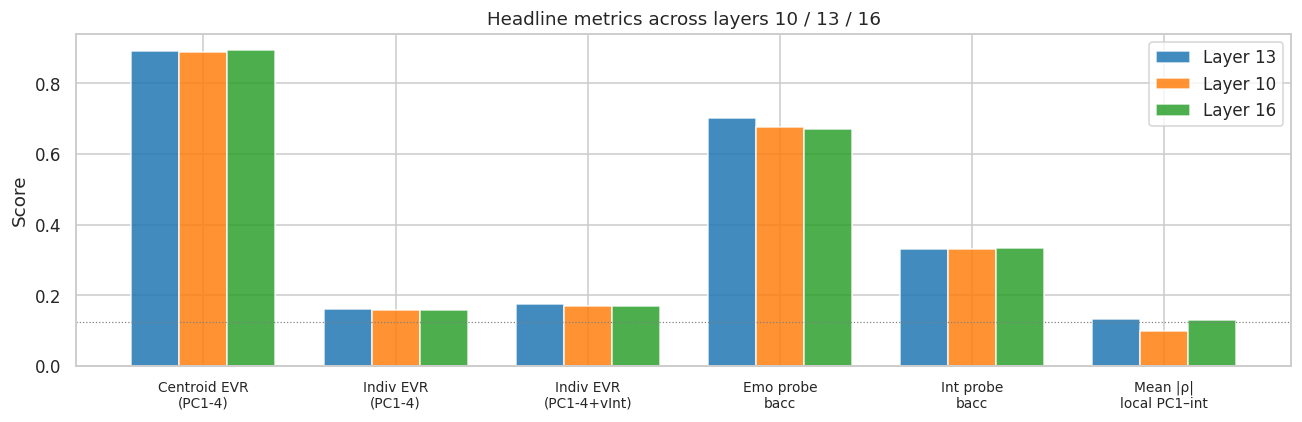

In [26]:
# ── Visual: grouped bar chart for the headline layer comparison ───────────────
metrics = ['centroid_evr4', 'indiv_evr_pc4', 'indiv_evr_pc4_vint',
           'emo_probe_bacc_pc4', 'int_probe_bacc_pc4', 'mean_local_pc1_int_rho']
labels  = ['Centroid EVR\n(PC1-4)', 'Indiv EVR\n(PC1-4)', 'Indiv EVR\n(PC1-4+vInt)',
           'Emo probe\nbacc', 'Int probe\nbacc', 'Mean |ρ|\nlocal PC1–int']

layers  = list(layer_df.index)
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(12, 4))
for i, (lay, col) in enumerate(zip(layers, colors)):
    vals = [float(layer_df.loc[lay, m]) for m in metrics]
    ax.bar(x + (i - 1) * width, vals, width, label=f'Layer {lay}', color=col, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Headline metrics across layers 10 / 13 / 16')
ax.legend()
ax.axhline(1/N_EMO, color='grey', ls=':', lw=0.8)   # chance for emotion probe
fig.tight_layout()
fig.savefig(OUT_DIR / 'layer_comparison_headline.png', dpi=140)
plt.show()


---
## 4. Summary

Save all headline numerics to `summary.json`.

In [27]:
summary = {
    # ── Analysis 1 ─────────────────────────────────────────────────────────
    'analysis_1_coverage': coverage_summary,

    # ── Analysis 2 ─────────────────────────────────────────────────────────
    'analysis_2_local_pca': {
        'layer': STEER_LAYER,
        'K_LOCAL': K_LOCAL,
        'per_emotion': {
            emo: {
                'participation_ratio': round(LOCAL_PCA[emo]['pr'], 3),
                'evr_k': [round(float(v), 4) for v in LOCAL_PCA[emo]['evr_k']],
                'evr_cum4': round(float(LOCAL_PCA[emo]['evr_k'][:4].sum()), 4),
                'local_pc1_int_spearman': round(float(int_rho_df.loc[emo, 'spearman_rho_pc1_int']), 4),
                'local_pc1_best_global': str(
                    ALIGN_DF[(ALIGN_DF.emotion == emo) & (ALIGN_DF.local_pc == 'PC1')]['best_match'].values[0]
                ),
                'local_pc1_max_cos_global': round(float(
                    ALIGN_DF[(ALIGN_DF.emotion == emo) & (ALIGN_DF.local_pc == 'PC1')]['max_cos'].values[0]
                ), 3),
            }
            for emo in EMOTION_ORDER
        },
    },

    # ── Layer comparison ────────────────────────────────────────────────────
    'layer_comparison': layer_df.round(4).to_dict(orient='index'),

    # ── Config ─────────────────────────────────────────────────────────────
    'config': {
        'steer_layer': STEER_LAYER,
        'aux_layers': AUX_LAYERS,
        'K_PCS': K_PCS,
        'K_LOCAL': K_LOCAL,
        'max_sources': MAX_SOURCES,
        'n_sources_used': N_SUB,
    },
}

out_path = OUT_DIR / 'summary.json'
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=2)
print('Wrote', out_path)
print('\nOutput files in', OUT_DIR, ':')
for p in sorted(OUT_DIR.iterdir()):
    print(f'  {p.name}')


Wrote /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/affective_subspace_coverage/summary.json

Output files in /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/affective_subspace_coverage :
  cross_emotion_local_pca_summary.png
  judge_attr_prediction_r2.csv
  judge_attr_prediction_r2.png
  layer_comparison_headline.csv
  layer_comparison_headline.png
  local_global_alignment.csv
  local_pc1_global_alignment.png
  local_pc1_intensity_spearman.csv
  local_pca_evr.csv
  local_pca_extremes.csv
  local_pca_pc12_scatter.png
  local_pca_scree_and_intensity.png
  per_emotion_evr.png
  per_emotion_reconstruction_evr.csv
  probe_accuracy_comparison.png
  probe_accuracy_summary.csv
  summary.json
